<h2 style='color:blue' align='center'>RiskProof AI: Logistic Regression Multiclass Classification</h2>

This notebook follows the same simple tutorial style as the reference digits notebook, but it is adapted to the `fraud_oracle.csv` dataset for the RiskProof AI project.

Here the multiclass target is `BasePolicy`, which has three classes:
- Collision
- Liability
- All Perils

The workflow is:
1. Import the required libraries.
2. Load the dataset.
3. Remove duplicates and missing values.
4. Encode the target and feature columns.
5. Train logistic regression with different parameters.
6. Predict, evaluate, and save the model with pickle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import joblib

%matplotlib inline

## 1. Load Dataset

In [2]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Clean Data

In [3]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('Missing values before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

Duplicates before: 0
Duplicates after: 0
Missing values before: 0
Missing values after: 0
Cleaned shape: (15420, 33)


## 3. Prepare Features and Target

Encoded input shape: (15420, 120)
Target classes: ['All Perils', 'Collision', 'Liability']
Target distribution:
BasePolicy
Collision     5962
Liability     5009
All Perils    4449
Name: count, dtype: int64
Unique encoded target values: [0 1 2]


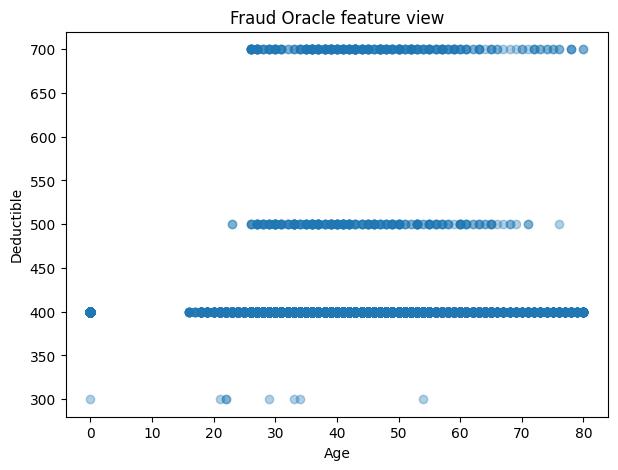

In [4]:
target_source = df['BasePolicy']
feature_source = df.drop(['BasePolicy', 'PolicyNumber', 'RepNumber', 'FraudFound_P'], axis='columns')

target_encoder = LabelEncoder()
target = target_encoder.fit_transform(target_source)

inputs = pd.get_dummies(feature_source, drop_first=True)

print('Encoded input shape:', inputs.shape)
print('Target classes:', list(target_encoder.classes_))
print('Target distribution:')
print(target_source.value_counts())
print('Unique encoded target values:', np.unique(target))

plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Deductible'], alpha=0.35)
plt.xlabel('Age')
plt.ylabel('Deductible')
plt.title('Fraud Oracle feature view')
plt.show()

## 4. Split Data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

print('Length of X_train:', len(X_train))
print('Length of X_test:', len(X_test))
print('Length of inputs:', len(inputs))

Length of X_train: 12336
Length of X_test: 3084
Length of inputs: 15420


## 5. Train Logistic Regression With Different Parameters

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

base_model = LogisticRegression(max_iter=5000, multi_class='multinomial', solver='lbfgs')
base_model.fit(X_train_scaled, y_train)
base_accuracy = base_model.score(X_test_scaled, y_test)
print('Base Logistic Regression accuracy:', base_accuracy)

best_model = None
best_accuracy = -1
best_c = None

for c_value in [0.1, 1.0, 5.0, 10.0]:
    model = LogisticRegression(max_iter=5000, multi_class='multinomial', solver='lbfgs', C=c_value)
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    print(f'C={c_value}, accuracy={score}')
    if score > best_accuracy:
        best_accuracy = score
        best_model = model
        best_c = c_value

print('Best C:', best_c)
print('Best accuracy:', best_accuracy)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=5000, multi_class='multinomial', solver='lbfgs', C=best_c),
    scaler.fit_transform(inputs),
    target,
    cv=5
)
print('Cross validation scores:', cv_scores)
print('Mean CV score:', cv_scores.mean())

C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Base Logistic Regression accuracy: 1.0


C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C=0.1, accuracy=1.0


C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Cross validation scores: [0.99967575 1.         1.         1.         1.        ]
Mean CV score: 0.999935149156939


## 6. Predict and Evaluate

In [7]:
y_pred = best_model.predict(X_test_scaled)
print('Sample predictions:', y_pred[:10])

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))

predicted_classes = target_encoder.inverse_transform(y_pred[:10])
print('Sample predicted classes:', predicted_classes)

Sample predictions: [0 1 2 1 1 1 2 1 0 0]
Confusion matrix:
 [[ 890    0    0]
 [   0 1192    0]
 [   0    0 1002]]
Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       890
           1       1.00      1.00      1.00      1192
           2       1.00      1.00      1.00      1002

    accuracy                           1.00      3084
   macro avg       1.00      1.00      1.00      3084
weighted avg       1.00      1.00      1.00      3084

Sample predicted classes: ['All Perils' 'Collision' 'Liability' 'Collision' 'Collision' 'Collision'
 'Liability' 'Collision' 'All Perils' 'All Perils']


## 7. Confusion Matrix

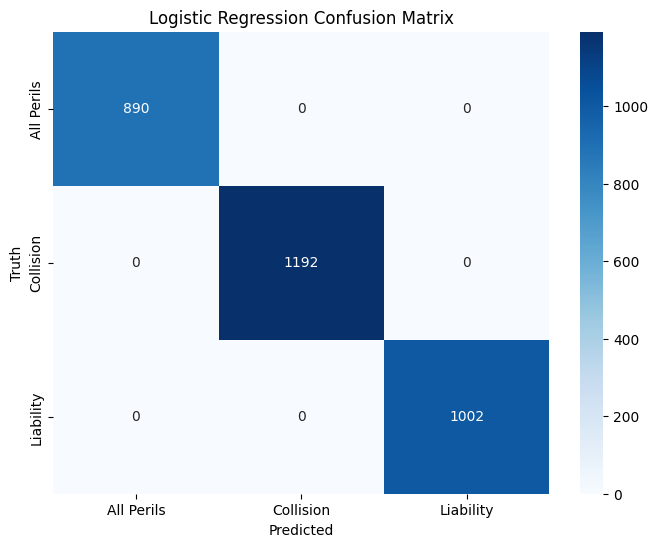

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

## 8. Save Model

In [9]:
model_bundle = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': inputs.columns.tolist(),
    'target_encoder': target_encoder,
    'best_c': best_c,
    'class_names': list(target_encoder.classes_)
}

with open('riskproof_logistic_regression_multiclass.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

joblib.dump(model_bundle, 'riskproof_logistic_regression_multiclass.joblib')
print('Saved model files: riskproof_logistic_regression_multiclass.pkl and riskproof_logistic_regression_multiclass.joblib')

Saved model files: riskproof_logistic_regression_multiclass.pkl and riskproof_logistic_regression_multiclass.joblib


## Conclusion

This notebook keeps the same tutorial style as the reference multiclass logistic regression notebook, but it is adapted to the RiskProof AI fraud dataset.

The final output is a multiclass logistic regression model that predicts the policy class, and the trained model is saved using pickle for later use in Google Colab.